# Notebook 05 — Market Coverage Matrix

Per-market audit: feature availability, year range, label coverage, and what's usable for each model horizon.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('../data/historical_dataset_clean.parquet')
print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Markets: {sorted(df.market.unique())}')

Dataset: 58,190 rows × 346 cols
Markets: ['BR', 'CA', 'DE', 'DK', 'ES', 'FI', 'FR', 'IT', 'JP', 'KR', 'NL', 'PT', 'SE', 'US']


## 1. Year Range and Row Count per Market

In [2]:
summary = []
for mkt, g in df.groupby('market'):
    row = {
        'market': mkt,
        'rows': len(g),
        'companies': g['ticker'].nunique(),
        'year_min': int(g['fiscal_year'].min()),
        'year_max': int(g['fiscal_year'].max()),
        'years_span': int(g['fiscal_year'].max() - g['fiscal_year'].min() + 1),
        'fraud_labels': int(g['fraud_confirmed'].sum()) if 'fraud_confirmed' in g.columns else 0,
        'fwd_1y_fill': g['forward_return_1y'].notna().mean(),
        'fwd_3y_fill': g['forward_return_3y'].notna().mean(),
        'fwd_5y_fill': g['forward_return_5y'].notna().mean(),
    }
    summary.append(row)

mkt_df = pd.DataFrame(summary).set_index('market')
mkt_df['fwd_1y_fill'] = mkt_df['fwd_1y_fill'].map('{:.1%}'.format)
mkt_df['fwd_3y_fill'] = mkt_df['fwd_3y_fill'].map('{:.1%}'.format)
mkt_df['fwd_5y_fill'] = mkt_df['fwd_5y_fill'].map('{:.1%}'.format)
print(mkt_df.to_string())

         rows  companies  year_min  year_max  years_span  fraud_labels fwd_1y_fill fwd_3y_fill fwd_5y_fill
market                                                                                                    
BR        688         48      2010      2025          16             0       87.2%       72.2%       58.0%
CA       8955       2005      2021      2026           6             0       75.0%       35.8%        0.0%
DE        356         77      2021      2025           5             0       80.3%       37.6%        0.0%
DK         71         15      2021      2025           5             0       78.9%       36.6%        0.0%
ES        169         35      2021      2026           6             0       78.7%       37.9%        0.0%
FI        116         25      2021      2025           5             0       73.3%       32.8%        0.0%
FR        193         40      2021      2025           5             0       78.2%       36.8%        0.0%
IT        192         40      2021   

## 2. Key Feature Fill Rate by Market

Grouped into factor families. Red = <30% fill (unusable), Orange = 30–70%, Green = >70%.

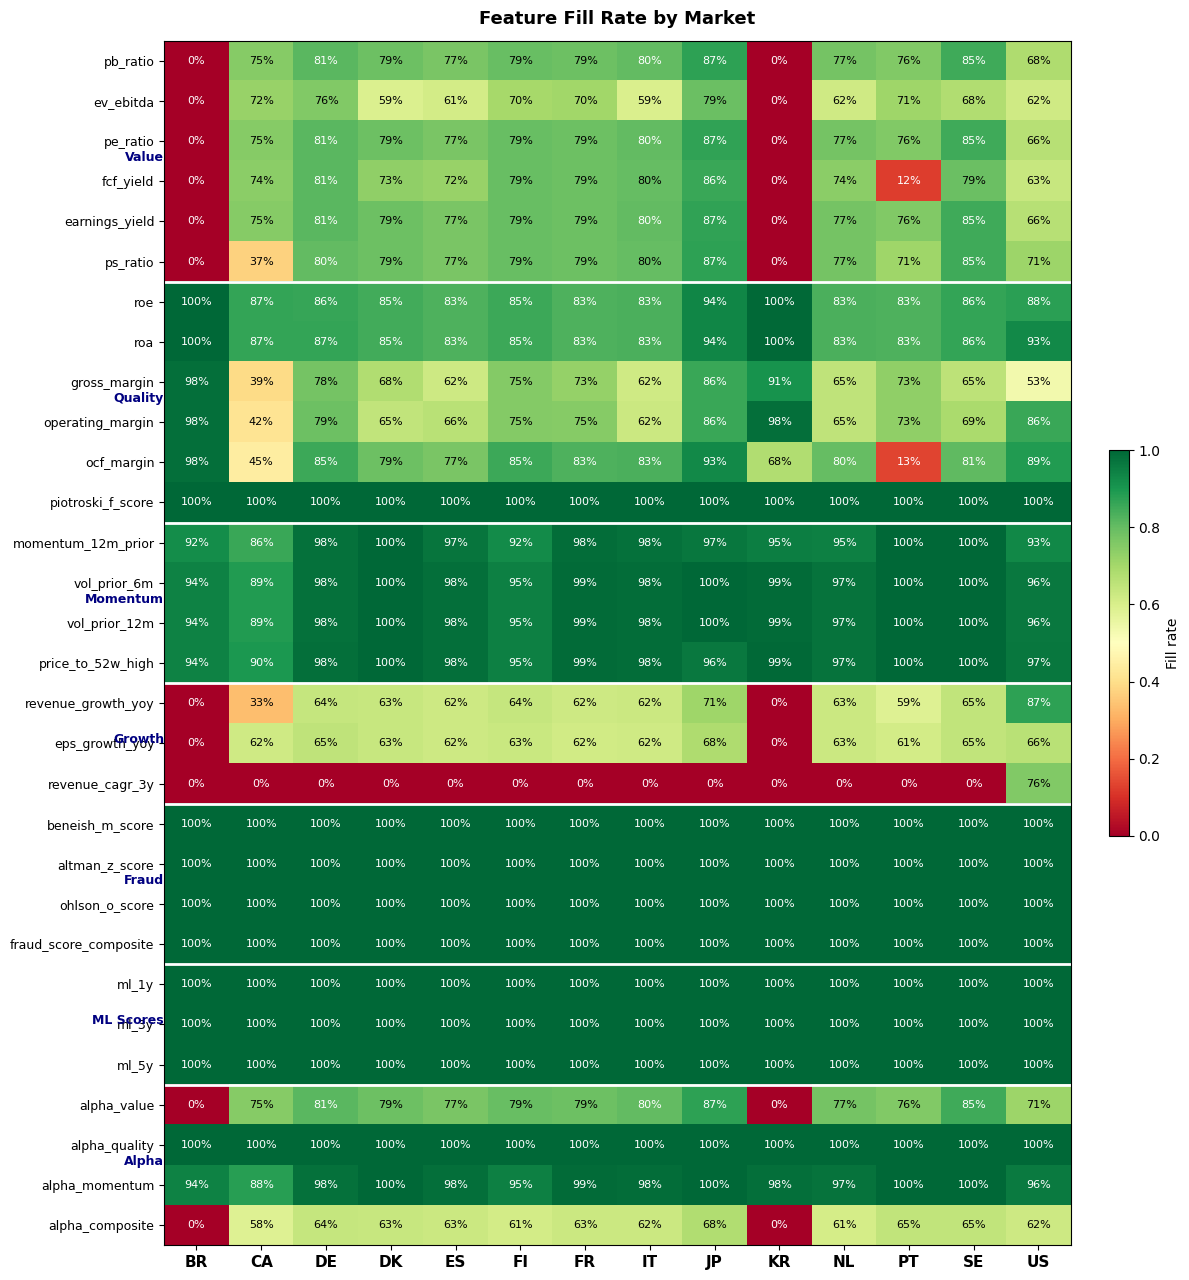

Saved → reports/market_coverage_matrix.png


In [3]:
FEATURE_GROUPS = {
    'Value': ['pb_ratio', 'ev_ebitda', 'pe_ratio', 'fcf_yield', 'earnings_yield', 'ps_ratio'],
    'Quality': ['roe', 'roa', 'gross_margin', 'operating_margin', 'ocf_margin', 'piotroski_f_score'],
    'Momentum': ['momentum_12m_prior', 'vol_prior_6m', 'vol_prior_12m', 'price_to_52w_high'],
    'Growth': ['revenue_growth_yoy', 'eps_growth_yoy', 'revenue_cagr_3y'],
    'Fraud': ['beneish_m_score', 'altman_z_score', 'ohlson_o_score', 'fraud_score_composite'],
    'ML Scores': ['ml_1y', 'ml_3y', 'ml_5y'],
    'Alpha': ['alpha_value', 'alpha_quality', 'alpha_momentum', 'alpha_composite'],
}

markets = sorted(df['market'].unique())
all_feats = [f for feats in FEATURE_GROUPS.values() for f in feats if f in df.columns]

fill_matrix = pd.DataFrame(index=all_feats, columns=markets)
for mkt in markets:
    g = df[df.market == mkt]
    for f in all_feats:
        fill_matrix.loc[f, mkt] = g[f].notna().mean() if f in g.columns else 0.0

fill_matrix = fill_matrix.astype(float)

fig, ax = plt.subplots(figsize=(12, len(all_feats) * 0.38 + 1.5))
cmap = plt.cm.RdYlGn
im = ax.imshow(fill_matrix.values, aspect='auto', cmap=cmap, vmin=0, vmax=1)
ax.set_xticks(range(len(markets)))
ax.set_xticklabels(markets, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(all_feats)))
ax.set_yticklabels(all_feats, fontsize=9)

# Draw group dividers
y = 0
for grp, feats in FEATURE_GROUPS.items():
    valid = [f for f in feats if f in df.columns]
    mid = y + len(valid) / 2 - 0.5
    ax.annotate(grp, xy=(-0.5, mid), xycoords=('data', 'data'),
                fontsize=9, color='navy', fontweight='bold', ha='right')
    if y > 0:
        ax.axhline(y - 0.5, color='white', linewidth=2)
    y += len(valid)

# Annotate cells
for i, f in enumerate(all_feats):
    for j, mkt in enumerate(markets):
        v = fill_matrix.loc[f, mkt]
        ax.text(j, i, f'{v:.0%}', ha='center', va='center',
                fontsize=8, color='black' if 0.3 < v < 0.8 else 'white')

plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04, label='Fill rate')
ax.set_title('Feature Fill Rate by Market', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../reports/market_coverage_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/market_coverage_matrix.png')

## 3. Model Usability Summary

For each market: which horizons have enough forward return labels, and which factor groups are usable.

In [4]:
usability = []
for mkt in markets:
    g = df[df.market == mkt]
    fy_span = int(g['fiscal_year'].max() - g['fiscal_year'].min() + 1) if len(g) else 0
    usability.append({
        'market': mkt,
        'years_span': fy_span,
        '1y_usable': '✅' if g['forward_return_1y'].notna().mean() > 0.5 else '❌',
        '3y_usable': '✅' if g['forward_return_3y'].notna().mean() > 0.5 else '❌',
        '5y_usable': '✅' if g['forward_return_5y'].notna().mean() > 0.5 else '❌',
        'value_ok':    '✅' if g['pb_ratio'].notna().mean() > 0.5 else '⚠️',
        'momentum_ok': '✅' if g['momentum_12m_prior'].notna().mean() > 0.5 else '⚠️',
        'fraud_ok':    '✅' if g['beneish_m_score'].notna().mean() > 0.5 else '⚠️',
        'fraud_labels': int(g.get('fraud_confirmed', pd.Series(0)).sum()),
        'note': ''
    })

usability_df = pd.DataFrame(usability).set_index('market')

# Add interpretive notes
notes = {
    'US':  'Full coverage; AAER labels; all 3 horizons',
    'KR':  'No market_cap → valuation nulls; 0 fraud labels; 1y/3y ok',
    'BR':  'No market_cap → valuation nulls; 0 fraud labels; 1y/3y ok',
    'EU':  '2021+ only → 0 5y labels; no AAER',
    'CA':  '2021+ only → 0 5y labels; no AAER',
    'JP':  '2021+ only → 0 5y labels; no AAER',
}
for mkt, note in notes.items():
    if mkt in usability_df.index:
        usability_df.loc[mkt, 'note'] = note

print(usability_df.to_string())

        years_span 1y_usable 3y_usable 5y_usable value_ok momentum_ok fraud_ok  fraud_labels                                                       note
market                                                                                                                                                 
BR              16         ✅         ✅         ✅       ⚠️           ✅        ✅             0  No market_cap → valuation nulls; 0 fraud labels; 1y/3y ok
CA               6         ✅         ❌         ❌        ✅           ✅        ✅             0                          2021+ only → 0 5y labels; no AAER
DE               5         ✅         ❌         ❌        ✅           ✅        ✅             0                                                           
DK               5         ✅         ❌         ❌        ✅           ✅        ✅             0                                                           
ES               6         ✅         ❌         ❌        ✅           ✅        ✅          

## 4. Forward Return Label Density by Market × Year

Shows which market-years actually have 1y and 5y return data.

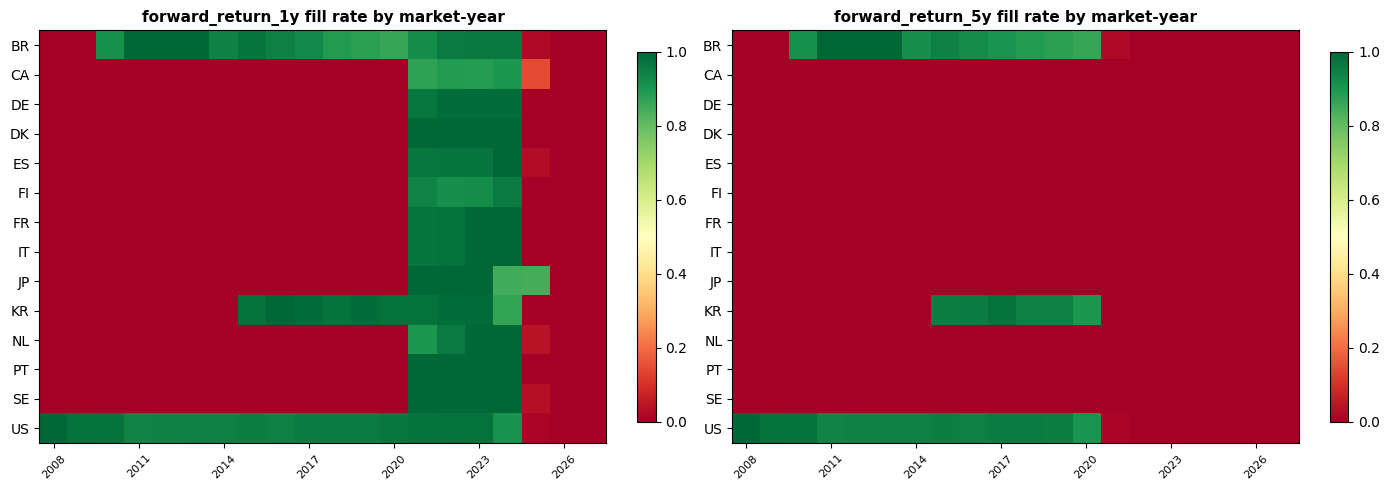

Saved → reports/market_label_density.png


In [5]:
years = sorted(df['fiscal_year'].dropna().unique().astype(int))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, horizon in zip(axes, ['forward_return_1y', 'forward_return_5y']):
    col = horizon if horizon in df.columns else None
    pivot = pd.DataFrame(index=markets, columns=years)
    for mkt in markets:
        g = df[df.market == mkt]
        for yr in years:
            gg = g[g['fiscal_year'] == yr]
            if col and len(gg):
                pivot.loc[mkt, yr] = gg[col].notna().mean()
            else:
                pivot.loc[mkt, yr] = 0.0
    pivot = pivot.astype(float)
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(0, len(years), 3))
    ax.set_xticklabels([years[i] for i in range(0, len(years), 3)], rotation=45, fontsize=8)
    ax.set_yticks(range(len(markets)))
    ax.set_yticklabels(markets, fontsize=10)
    ax.set_title(f'{horizon} fill rate by market-year', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.03)

plt.tight_layout()
plt.savefig('../reports/market_label_density.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/market_label_density.png')

## 5. Known Limitations Summary

| Market | Limitation | Implication |
|---|---|---|
| KR | No market_cap_at_filing | pb_ratio, ev_ebitda, altman_x4 all null; value features useless |
| BR | No market_cap_at_filing | Same as KR |
| EU/CA/JP | Only 2021–2025 | Insufficient history for 5y labels; momentum features unreliable |
| All non-US | No AAER labels | fraud_confirmed=0; ML model can't train on fraud signal for these |
| All non-US | SPY benchmark not used | Excess return vs local index only |